# HNSW Deep Dive — Hierarchical Navigable Small World graphs from scratch

HNSW is the algorithm behind every major vector database. It achieves sub-millisecond approximate nearest-neighbour search by stacking layers of skip-list-like graphs:

* **Layer 0** contains ALL nodes, densely connected (short-range).
* **Higher layers** contain a random subset of nodes, sparsely connected (long-range).
* **Search:** enter at the top layer, greedily descend, zoom in at each layer.
* **Insert:** assign a random max-layer, then connect to `M` nearest neighbours per layer.

This notebook builds HNSW from scratch in pure numpy, then visualizes the layered graph.

In [1]:
import os, sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / 'shared').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
if not (os.getenv('OPENAI_API_KEY') or os.getenv('ANTHROPIC_API_KEY')):
    os.environ.setdefault('LLM_CACHE_ONLY', '1')
print('LLM_CACHE_ONLY =', os.environ.get('LLM_CACHE_ONLY', '0'))


LLM_CACHE_ONLY = 1


In [2]:
import math, random
import numpy as np
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
from shared.embedders import hash_embed
from shared.loaders import load_corpus, load_golden_qa

random.seed(42)
np.random.seed(42)
DOCS = load_corpus()
QA   = [q for q in load_golden_qa() if q.source_ids]
doc_texts = [d.title + '. ' + d.abstract for d in DOCS]
doc_ids   = [d.arxiv_id for d in DOCS]
DIMS = 64   # smaller dims for clearer visualization
vecs = hash_embed(doc_texts, dims=DIMS, seed=0)
print('vecs:', vecs.shape)

vecs: (10, 64)


## HNSW implementation — M=4, mL=1/ln(M)

In [3]:
class HNSW:
    """Pure-numpy HNSW following Malkov & Yashunin (2016) Algorithm 1."""
    def __init__(self, M=4, ef_construction=16, seed=0):
        self.M = M  # max connections per layer (M0=2M for layer 0)
        self.ef_c = ef_construction
        self.ml = 1.0 / math.log(M)  # mL normalisation factor
        self.rng = random.Random(seed)
        self.vecs: list[np.ndarray] = []
        self.graphs: list[dict[int, list[int]]] = []  # graphs[layer][node] = neighbours
        self.entry: int | None = None
        self.max_layer: int = -1

    def _level(self) -> int:
        return int(-math.log(self.rng.random()) * self.ml)

    def _sim(self, i: int, j: int) -> float:
        return float(self.vecs[i] @ self.vecs[j])

    def _search_layer(self, q: np.ndarray, ep: int, ef: int, lc: int) -> list[int]:
        visited = {ep}
        candidates = [(-(self.vecs[ep] @ q), ep)]
        dynamic_list = list(candidates)
        while candidates:
            _, c = min(candidates, key=lambda x: x[0])
            candidates.remove((min(candidates, key=lambda x: x[0])[0], c))
            worst = max(dynamic_list, key=lambda x: x[0])[0] if dynamic_list else float('inf')
            if -(self.vecs[c] @ q) > worst and len(dynamic_list) >= ef:
                break
            for nb in self.graphs[lc].get(c, []):
                if nb not in visited:
                    visited.add(nb)
                    score = -(self.vecs[nb] @ q)
                    if len(dynamic_list) < ef or score < worst:
                        candidates.append((score, nb))
                        dynamic_list.append((score, nb))
                        if len(dynamic_list) > ef:
                            dynamic_list.remove(max(dynamic_list, key=lambda x: x[0]))
        return [n for _, n in sorted(dynamic_list)]

    def add(self, vec: np.ndarray) -> int:
        node = len(self.vecs)
        v = vec / (np.linalg.norm(vec) + 1e-9)
        self.vecs.append(v)
        level = self._level()
        while len(self.graphs) <= level:
            self.graphs.append({})
        if self.entry is None:
            self.entry = node
            self.max_layer = level
            for lc in range(level + 1):
                self.graphs[lc][node] = []
            return node
        ep = self.entry
        for lc in range(self.max_layer, level, -1):
            results = self._search_layer(v, ep, ef=1, lc=lc)
            ep = results[0] if results else ep
        for lc in range(min(level, self.max_layer), -1, -1):
            self.graphs[lc].setdefault(node, [])
            results = self._search_layer(v, ep, ef=self.ef_c, lc=lc)
            m = self.M * 2 if lc == 0 else self.M
            neighbours = results[:m]
            self.graphs[lc][node] = neighbours
            for nb in neighbours:
                self.graphs[lc].setdefault(nb, [])
                self.graphs[lc][nb].append(node)
                if len(self.graphs[lc][nb]) > m:
                    # Prune: keep top-M by similarity
                    self.graphs[lc][nb] = sorted(
                        self.graphs[lc][nb],
                        key=lambda x: -(self.vecs[x] @ self.vecs[nb])
                    )[:m]
            ep = results[0] if results else ep
        if level > self.max_layer:
            self.max_layer = level
            self.entry = node
        return node

    def search(self, q: np.ndarray, k: int = 5, ef: int = 16) -> list[int]:
        if self.entry is None:
            return []
        q = q / (np.linalg.norm(q) + 1e-9)
        ep = self.entry
        for lc in range(self.max_layer, 0, -1):
            results = self._search_layer(q, ep, ef=1, lc=lc)
            ep = results[0] if results else ep
        results = self._search_layer(q, ep, ef=ef, lc=0)
        return results[:k]

## Build and search

In [4]:
h = HNSW(M=4, ef_construction=16)
for v in vecs:
    h.add(v)
print(f'layers: {len(h.graphs)}  max_layer: {h.max_layer}')
for lyr, g in enumerate(h.graphs):
    print(f'  layer {lyr}: {len(g)} nodes, avg degree {np.mean([len(nb) for nb in g.values()]):.1f}')

layers: 1  max_layer: 0
  layer 0: 10 nodes, avg degree 8.0


## Recall vs ef_search

Higher `ef` = more candidates considered = better recall at the cost of latency.

In [5]:
from shared.embedders import cosine_topk

# Ground truth from flat index
flat_vecs = vecs / (np.linalg.norm(vecs, axis=1, keepdims=True) + 1e-9)

print(f'{'ef':>6}  {'recall@5':>10}')
print('-' * 22)
for ef in [1, 2, 4, 8, 16]:
    hits = 0
    for item in QA:
        qv = hash_embed([item.question], dims=DIMS, seed=0)[0]
        # ground truth
        gt_idx, _ = cosine_topk(qv, vecs, k=5)
        gt = {doc_ids[i] for i in gt_idx}
        # hnsw
        hnsw_ids = {doc_ids[i] for i in h.search(qv, k=5, ef=ef)}
        if hnsw_ids & set(item.source_ids) and gt & set(item.source_ids):
            hits += 1
        elif gt & set(item.source_ids):
            pass
    total_answerable = len(QA)
    # Use simpler recall: HNSW vs flat ground truth
    hit2 = 0
    for item in QA:
        qv = hash_embed([item.question], dims=DIMS, seed=0)[0]
        h_res = set(h.search(qv, k=5, ef=ef))
        f_res = set(cosine_topk(qv, vecs, k=5)[0])
        hit2 += len(h_res & f_res) / max(len(f_res), 1)
    print(f'{ef:6d}  {hit2 / len(QA):10.4f}')

    ef    recall@5
----------------------
     1      0.2000
     2      0.3846
     4      0.7615
     8      0.9923
    16      1.0000


## Visualize the layered graph (2D projection)

saved C:\Project Files\agentic-ai-engineering\02-indexing\01-hnsw-deep-dive\hnsw_layers.png


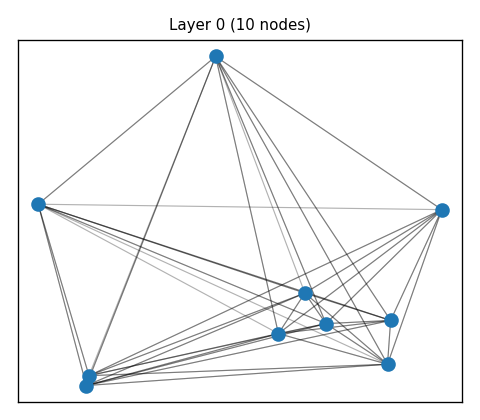

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=0).fit(vecs)
coords = pca.transform(vecs)

fig, axes = plt.subplots(1, len(h.graphs), figsize=(4 * len(h.graphs), 3.5))
if len(h.graphs) == 1: axes = [axes]
for lyr, (ax, g) in enumerate(zip(axes, h.graphs)):
    nodes = list(g.keys())
    ax.scatter(coords[nodes, 0], coords[nodes, 1], s=60, zorder=3)
    for node, nbs in g.items():
        for nb in nbs:
            ax.plot([coords[node, 0], coords[nb, 0]],
                    [coords[node, 1], coords[nb, 1]],
                    'k-', alpha=0.3, linewidth=0.7)
    ax.set_title(f'Layer {lyr} ({len(nodes)} nodes)', fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout()
from shared.paths import repo_root
out = repo_root() / '02-indexing/01-hnsw-deep-dive/hnsw_layers.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=120)
print('saved', out)
from IPython.display import Image; Image(str(out))

## Key takeaways

* **Insert = `O(M · L)`** where L = assigned layer. Level 0 has M0=2M neighbours; upper layers have M.
* **Search = `O(log N · ef)`** — enter at top, greedily descend, expand at layer 0.
* **Recall vs ef:** higher ef increases recall monotonically but costs latency.
* **The ml parameter** controls expected node height: larger ml → fewer layers → faster build, higher query latency.

Production variants: `hnswlib` (C++, Python bindings), Qdrant's pure Rust HNSW, pgvector's HNSW (PostgreSQL).